# EDA: English → Igbo Parallel Corpus

Milestone 2 data understanding (see `docs/TODO.md`). Dataset:
`data/benchmark_dataset/{train,val,test}_{en,ig}.txt`, from the Ezeani et al.
2020 Igbo-English MT benchmark. Direction: **English → Igbo**.

Steps:
1. Load and sanity-check the three splits
2. Raw baseline stats (no normalization) — vocab size, singleton rate, EN∩IG overlap, OOV
3. Normalize (lowercase + isolate punctuation, no accent-stripping on Igbo)
4. Re-measure vocab/singleton/OOV after normalization
5. Length distribution → pick `MAX_LENGTH` and length buckets for Milestone 5
6. Final vocabulary + tokenization decision
7. Dataset spec (per `TODO.md`'s template)

In [1]:
import sys
from pathlib import Path
from collections import Counter
import statistics as st

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.normalize import normalize_en, normalize_ig
from src.vocab import Vocab
from src.dataset import load_pairs

DATA_DIR = PROJECT_ROOT / "data" / "benchmark_dataset"
DATA_DIR

WindowsPath('C:/Users/ecole/CoreML-Ayush/LSTM-Seq2Seq-Machine-Translation/data/benchmark_dataset')

## 1. Load and sanity-check the splits

Line counts must match between the English and Igbo file of each split
(they're aligned by line), and a spot check should show real translation
pairs, not garbage/misalignment.

In [2]:
SPLITS = ["train", "val", "test"]

raw_pairs = {}
for split in SPLITS:
    src_path = DATA_DIR / f"{split}_en.txt"
    tgt_path = DATA_DIR / f"{split}_ig.txt"
    # identity normalize here -- just checking raw alignment/line counts
    pairs = load_pairs(src_path, tgt_path, lambda s: s.strip(), lambda s: s.strip())
    raw_pairs[split] = pairs
    print(f"{split:>5}: {len(pairs)} pairs")

print()
print("Spot check (train, first 3 pairs):")
for en, ig in raw_pairs["train"][:3]:
    print("EN:", en)
    print("IG:", ig)
    print()

train: 10000 pairs
  val: 193 pairs
 test: 597 pairs

Spot check (train, first 3 pairs):
EN: The news that will interest you:
IG: Akụkọ ndị ga-amasị gị:

EN: Joseph Achuzie, the Biafran brave man is gone.
IG: Joseph Achuzie, Dike Biafra alala

EN: Dapchi: Government has not defeated Boko Haram and Massob
IG: Dapchi: Gọọmenti emeribeghị Boko Haram - Massob



## 2. Raw baseline stats (before any normalization)

Split purely on whitespace, no lowercasing or punctuation handling. This is
the "before" picture that motivated normalizing before deciding on
word-level tokenization.

In [ ]:
def whitespace_toks(sentence):
    return sentence.split()


def vocab_stats(pairs, idx):
    counter = Counter(w for pair in pairs for w in whitespace_toks(pair[idx]))  # For every pair → select one sentence → split it into words → take every word → count all those words.
    singleton = sum(1 for c in counter.values() if c == 1)
    return counter, singleton


def oov_rate(pairs, idx, train_vocab):
    total = sum(len(whitespace_toks(pair[idx])) for pair in pairs)
    oov = sum(
        1
        for pair in pairs
        for w in whitespace_toks(pair[idx])
        if w not in train_vocab
    )
    return oov, total, oov / total


en_counter_raw, en_singleton_raw = vocab_stats(raw_pairs["train"], 0)
ig_counter_raw, ig_singleton_raw = vocab_stats(raw_pairs["train"], 1)

print("RAW (whitespace-only) baseline, train split:")
print(f"  EN vocab size: {len(en_counter_raw)}, singleton rate: {en_singleton_raw / len(en_counter_raw):.1%}")
print(f"  IG vocab size: {len(ig_counter_raw)}, singleton rate: {ig_singleton_raw / len(ig_counter_raw):.1%}")

en_oov = oov_rate(raw_pairs["val"], 0, set(en_counter_raw))
ig_oov = oov_rate(raw_pairs["val"], 1, set(ig_counter_raw))
print(f"  EN val OOV rate: {en_oov[2]:.1%} ({en_oov[0]}/{en_oov[1]} tokens)")
print(f"  IG val OOV rate: {ig_oov[2]:.1%} ({ig_oov[0]}/{ig_oov[1]} tokens)")

RAW (whitespace-only) baseline, train split:


  EN vocab size: 23764, singleton rate: 53.3%
  IG vocab size: 21789, singleton rate: 57.0%
  EN val OOV rate: 14.4% (616/4292 tokens)
  IG val OOV rate: 10.9% (495/4538 tokens)


In [4]:
overlap = set(en_counter_raw) & set(ig_counter_raw)
print(f"Exact string overlap EN ∩ IG: {len(overlap)}")
print("Sample (mostly proper nouns / numbers / punctuation-glued tokens, not real collisions):")
print(sorted(overlap)[:30])

Exact string overlap EN ∩ IG: 5440
Sample (mostly proper nouns / numbers / punctuation-glued tokens, not real collisions):
['#', '#BBCNigeria2019', '#BetterChallenge.', '#FreeSowore', '#FreeSowore:', '#LazyNigerianYouths', '#NoBraDay', '#NoBraDay.', '#NoBraDay:', '#RevolutionNow', '$', '$100.', '$1000', '$10tn', '$2.22', '$200', '$5.2', '$50.', '$5000', '$50?', '$60b', '$7.19', '&', "'", "',", "'.", "'A", "'African", "'Agbanabo'", "'Airbnb'"]


## 3. Normalize

Lowercase + isolate punctuation as its own token (see `src/normalize.py`).
Critically, **no Unicode accent-stripping is applied to the Igbo side** --
because `unicodeToAscii` (NFD-decompose + drop category
`Mn`) would turn `ị→i`, `ọ→o`, `ụ→u`, corrupting distinct Igbo
phonemes. Verify the dotted vowels survive normalization unchanged.

In [5]:
diacritic_samples = ["ị", "ọ", "ụ", "akwụkwọ", "ndụ"]
for s in diacritic_samples:
    print(f"{s!r:>12} -> {normalize_ig(s)!r}")

assert normalize_ig("akwụkwọ") == "akwụkwọ", "Igbo diacritics were stripped!"
print("\nOK: Igbo diacritics survive normalization unchanged.")

         'ị' -> 'ị'
         'ọ' -> 'ọ'
         'ụ' -> 'ụ'
   'akwụkwọ' -> 'akwụkwọ'
       'ndụ' -> 'ndụ'

OK: Igbo diacritics survive normalization unchanged.


In [6]:
norm_pairs = {}
for split in SPLITS:
    src_path = DATA_DIR / f"{split}_en.txt"
    tgt_path = DATA_DIR / f"{split}_ig.txt"
    norm_pairs[split] = load_pairs(src_path, tgt_path, normalize_en, normalize_ig)

print("Normalized sample (train, first pair):")
print("EN:", norm_pairs["train"][0][0])
print("IG:", norm_pairs["train"][0][1])

Normalized sample (train, first pair):
EN: the news that will interest you :
IG: akụkọ ndị ga - amasị gị :


## 4. Re-measure after normalization

Same vocab-size / singleton-rate / OOV-rate measurements as step 2, now on
normalized tokens. This is the number that actually decides word-level vs.
subword -- not the raw baseline above.

In [7]:
en_counter_norm, en_singleton_norm = vocab_stats(norm_pairs["train"], 0)
ig_counter_norm, ig_singleton_norm = vocab_stats(norm_pairs["train"], 1)

print("NORMALIZED baseline, train split:")
print(f"  EN vocab size: {len(en_counter_norm)}, singleton rate: {en_singleton_norm / len(en_counter_norm):.1%}")
print(f"  IG vocab size: {len(ig_counter_norm)}, singleton rate: {ig_singleton_norm / len(ig_counter_norm):.1%}")

en_oov_n = oov_rate(norm_pairs["val"], 0, set(en_counter_norm))
ig_oov_n = oov_rate(norm_pairs["val"], 1, set(ig_counter_norm))
print(f"  EN val OOV rate: {en_oov_n[2]:.1%} ({en_oov_n[0]}/{en_oov_n[1]} tokens)")
print(f"  IG val OOV rate: {ig_oov_n[2]:.1%} ({ig_oov_n[0]}/{ig_oov_n[1]} tokens)")

print()
print("Before vs after normalization:")
print(f"  EN vocab: {len(en_counter_raw)} -> {len(en_counter_norm)}")
print(f"  IG vocab: {len(ig_counter_raw)} -> {len(ig_counter_norm)}")
print(f"  EN val OOV: {en_oov[2]:.1%} -> {en_oov_n[2]:.1%}")
print(f"  IG val OOV: {ig_oov[2]:.1%} -> {ig_oov_n[2]:.1%}")

NORMALIZED baseline, train split:


  EN vocab size: 14211, singleton rate: 40.2%
  IG vocab size: 13576, singleton rate: 48.3%
  EN val OOV rate: 7.1% (357/5056 tokens)
  IG val OOV rate: 5.6% (316/5622 tokens)

Before vs after normalization:
  EN vocab: 23764 -> 14211
  IG vocab: 21789 -> 13576
  EN val OOV: 14.4% -> 7.1%
  IG val OOV: 10.9% -> 5.6%


**Result of running this notebook once:**

| | EN | IG |
|---|---:|---:|
| vocab size (raw → normalized) | 23,764 → 14,211 | 21,789 → 13,576 |
| singleton rate (raw → normalized) | 53.3% → 40.2% | 57.0% → 48.3% |
| val OOV rate (raw → normalized) | 14.4% → 7.1% | 10.9% → 5.6% |

Normalization roughly halves OOV and cuts vocab size by ~35-40%, but
singleton rate is still ~40-48% and OOV is still ~6-7% — word-level
tokenization on 10k training sentences is still fairly sparse.

**Decision: keep normalized word-level tokenization for this project.**
`TODO.md`'s stated goal for Milestone 3+ is to *expose the fixed-context
bottleneck* of a vanilla encoder-decoder, not to maximize translation
quality — word-level is the simplest thing that lets that architectural
point be demonstrated cleanly. The residual OOV/singleton rate is a real
limitation and the honest reason translation *quality* itself would likely
improve with subword (BPE) tokenization; that remains a documented,
not-yet-implemented option in `src/vocab.py` if this project's goal shifts
from "show the bottleneck" to "get the best possible translations."

## 5. Length distribution

Milestone 5's whole point is
to compare model behavior across short/medium/long/very-long source
sentences, so long sentences must stay in the data. Instead we look at the
real percentile distribution and pick a generous `MAX_LENGTH` cutoff
(truncating only the extreme tail) and bucket boundaries for Milestone 5.

EN: mean=19.9 median=18.0 p90=36 p95=43 p99=62 max=118
IG: mean=22.9 median=21.0 p90=42 p95=52 p99=71 max=148


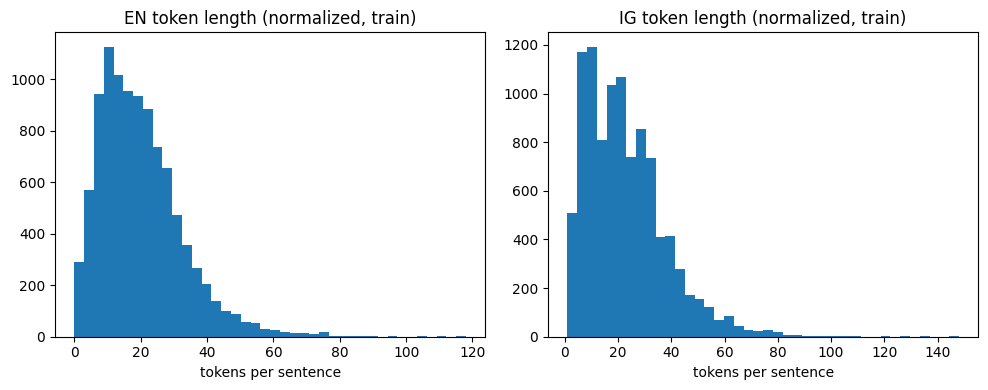

In [8]:
def token_lengths(pairs, idx):
    return [len(whitespace_toks(p[idx])) for p in pairs]


def percentile(sorted_lens, p):
    idx = int(len(sorted_lens) * p)
    return sorted_lens[min(idx, len(sorted_lens) - 1)]


en_lens = sorted(token_lengths(norm_pairs["train"], 0))
ig_lens = sorted(token_lengths(norm_pairs["train"], 1))

for name, lens in [("EN", en_lens), ("IG", ig_lens)]:
    print(
        f"{name}: mean={st.mean(lens):.1f} median={st.median(lens)} "
        f"p90={percentile(lens, 0.90)} p95={percentile(lens, 0.95)} "
        f"p99={percentile(lens, 0.99)} max={max(lens)}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(en_lens, bins=40)
axes[0].set_title("EN token length (normalized, train)")
axes[1].hist(ig_lens, bins=40)
axes[1].set_title("IG token length (normalized, train)")
for ax in axes:
    ax.set_xlabel("tokens per sentence")
plt.tight_layout()
plt.show()

**Result of running this notebook once:**

- EN: mean 19.9, median 18, p90=36, p95=43, p99=62, max=118
- IG: mean 22.9, median 21, p90=42, p95=52, p99=71, max=148

**`MAX_LENGTH = 80`**: covers the 99th percentile of both languages
(EN p99=62, IG p99=71) with margin, truncating only the most extreme ~1%
tail instead of dropping long sentences.

**Length buckets for Milestone 5** (source/English length, in tokens),
chosen from the EN percentiles above:

| bucket | tokens |
|---|---|
| short | 1–15 |
| medium | 16–30 |
| long | 31–50 |
| very long | 51+ |

In [9]:
MAX_LENGTH = 80

LENGTH_BUCKETS = [
    ("short", 1, 15),
    ("medium", 16, 30),
    ("long", 31, 50),
    ("very long", 51, float("inf")),
]


def bucket_for(length):
    for name, lo, hi in LENGTH_BUCKETS:
        if lo <= length <= hi:
            return name
    return "very long"


bucket_counts = Counter(bucket_for(l) for l in en_lens)
for name, _, _ in LENGTH_BUCKETS:
    n = bucket_counts[name]
    print(f"{name:>10}: {n:5d} ({n / len(en_lens):.1%})")

truncated = sum(1 for l in en_lens if l > MAX_LENGTH) + sum(1 for l in ig_lens if l > MAX_LENGTH)
print(f"\nSentences exceeding MAX_LENGTH={MAX_LENGTH} (either side): {truncated}")

     short:  4263 (42.6%)
    medium:  3997 (40.0%)
      long:  1470 (14.7%)
 very long:   270 (2.7%)

Sentences exceeding MAX_LENGTH=80 (either side): 57


## 6. Final vocabulary

Build the real `Vocab` objects (`src/vocab.py`) from the **train** split
only — separate English and Igbo vocabularies, per
`docs/embedding_and_tokenization_reasoning.md`. `Vocab` reserves 4 special
tokens (`<PAD>`, `<SOS>`, `<EOS>`, `<UNK>`), so final sizes are the raw
counter sizes above + 4.

In [10]:
en_vocab = Vocab("en")
ig_vocab = Vocab("ig")
for en, ig in norm_pairs["train"]:
    en_vocab.add_sentence(en)
    ig_vocab.add_sentence(ig)

print(f"EN vocab (incl. special tokens): {en_vocab.n_words}")
print(f"IG vocab (incl. special tokens): {ig_vocab.n_words}")

# round-trip sanity check
sample_en, sample_ig = norm_pairs["train"][0]
ids = en_vocab.sentence_to_ids(sample_en, MAX_LENGTH)
print("\nRound-trip check:")
print("original :", sample_en)
print("decoded  :", en_vocab.ids_to_sentence(ids))

EN vocab (incl. special tokens): 14215
IG vocab (incl. special tokens): 13580

Round-trip check:
original : the news that will interest you :
decoded  : the news that will interest you :


In [11]:
from src.dataset import encode_pairs, make_dataloader

dataloaders = {}
for split in SPLITS:
    input_ids, target_ids = encode_pairs(norm_pairs[split], en_vocab, ig_vocab, MAX_LENGTH)
    dataloaders[split] = make_dataloader(
        input_ids, target_ids, batch_size=32, shuffle=(split == "train")
    )
    batch_in, batch_tgt = next(iter(dataloaders[split]))
    print(f"{split:>5}: input {tuple(batch_in.shape)}, target {tuple(batch_tgt.shape)}")

train: input (32, 80), target (32, 80)
  val: input (32, 80), target (32, 80)
 test: input (32, 80), target (32, 80)


## 7. Dataset spec

Per `docs/TODO.md`'s Milestone 2 deliverable template.

```text
Dataset:  English-Igbo parallel corpus (Ezeani et al. 2020, Igbo-English MT
          Evaluation Benchmark), data/benchmark_dataset/
Task:     Machine translation, English -> Igbo
Source:   English sentence (news domain: BBC Igbo / Nigerian newspapers)
Target:   Igbo sentence
# examples: train 10,000 | val 193 | test 597

source length distribution (English, normalized tokens, train):
  mean 19.9, median 18, p90 36, p95 43, p99 62, max 118
  buckets: short 1-15 | medium 16-30 | long 31-50 | very long 51+

target length distribution (Igbo, normalized tokens, train):
  mean 22.9, median 21, p90 42, p95 52, p99 71, max 148

tokenization: word-level, whitespace split after normalization
  (lowercase + punctuation isolated as its own token; no Unicode
  accent-stripping on Igbo -- see docs/embedding_and_tokenization_reasoning.md)
  MAX_LENGTH = 80 (covers p99 of both languages)

vocabulary: separate per language, built from train split only
  EN: 14,211 word types + 4 special tokens (<PAD> <SOS> <EOS> <UNK>)
  IG: 13,576 word types + 4 special tokens
  val OOV rate against train vocab: EN 7.1%, IG 5.6%
```